In [ ]:
import json, math
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = None
plt.rcParams["figure.dpi"] = 120

#  Load any run folder

In [12]:
EXP_ROOT = Path("experiments")         

def load_run(path: Path) -> Dict:
    """Return a flat dict with metrics + config for one experiment folder."""
    out = {"folder": path.name}
    # core config / metrics
    for fname in ("config.json", "metrics.json",
                  "text_image_metrics.json", "image_image_metrics.json"):
        f = path / fname
        if f.exists():
            out.update(json.loads(f.read_text()))
    return out if len(out) > 1 else None

# Gather all runs into a DataFrame

In [13]:
records: List[Dict] = []
for p in EXP_ROOT.iterdir():
    if p.is_dir():
        run = load_run(p)
        if run:
            records.append(run)

df = pd.DataFrame(records).sort_values("folder").reset_index(drop=True)
df.head()

,folder,device,model,pretrained,batch,max_samples,parquet,R@1,R@5,R@10,median_rank,cross_domain_R@1,cross_domain_R@5,cross_domain_R@10,embed_secs,param_count
0,RN50_20250623_213349,cpu,RN50,openai,64,100,C:\Users\steph\OneDrive\Desktop\data\metadata....,89.00,97.00,98.00,1.0,NaN,NaN,NaN,NaN,NaN
1,RN50_20250623_213537,cpu,RN50,openai,64,100,C:\Users\steph\OneDrive\Desktop\data\metadata....,78.00,96.00,98.00,1.0,NaN,NaN,NaN,NaN,NaN
2,RN50_20250623_214602,cpu,RN50,openai,64,2000,C:\Users\steph\OneDrive\Desktop\data\metadata....,48.35,76.55,85.20,2.0,23.85,54.85,67.4,NaN,NaN
3,ViT-B-32_20250624_170054,cpu,ViT-B-32,laion2b_s34b_b79k,64,10000,NaN,43.09,66.63,75.29,NaN,NaN,NaN,NaN,1280.8,151277313.0


# Clean up & add helper columns

In [ ]:
import pandas as pd
import numpy as np

df["samples"] = pd.NA

if "max_samples" in df.columns:
    df.loc[df["samples"].isna(), "samples"] = df["max_samples"]

if "samples" in df.columns:
    df["samples"].fillna(df["samples"], inplace=True)

if "ids" in df.columns:
    df.loc[df["samples"].isna(), "samples"] = df["ids"].apply(len)

df["samples"] = df["samples"].astype("Int64")

df["label"] = (
    df.get("model", df.get("model_name", "unknown")).astype(str)
    + "_" + df["folder"].str[-4:]
)

df.head()


,folder,device,model,pretrained,batch,max_samples,parquet,R@1,R@5,R@10,median_rank,cross_domain_R@1,cross_domain_R@5,cross_domain_R@10,embed_secs,param_count,samples,label
0,RN50_20250623_213349,cpu,RN50,openai,64,100,C:\Users\steph\OneDrive\Desktop\data\metadata....,89.00,97.00,98.00,1.0,NaN,NaN,NaN,NaN,NaN,100,RN50_3349
1,RN50_20250623_213537,cpu,RN50,openai,64,100,C:\Users\steph\OneDrive\Desktop\data\metadata....,78.00,96.00,98.00,1.0,NaN,NaN,NaN,NaN,NaN,100,RN50_3537
2,RN50_20250623_214602,cpu,RN50,openai,64,2000,C:\Users\steph\OneDrive\Desktop\data\metadata....,48.35,76.55,85.20,2.0,23.85,54.85,67.4,NaN,NaN,2000,RN50_4602
3,ViT-B-32_20250624_170054,cpu,ViT-B-32,laion2b_s34b_b79k,64,10000,NaN,43.09,66.63,75.29,NaN,NaN,NaN,NaN,1280.8,151277313.0,10000,ViT-B-32_0054


# Plot Recall@K vs sample count (text-to-image)

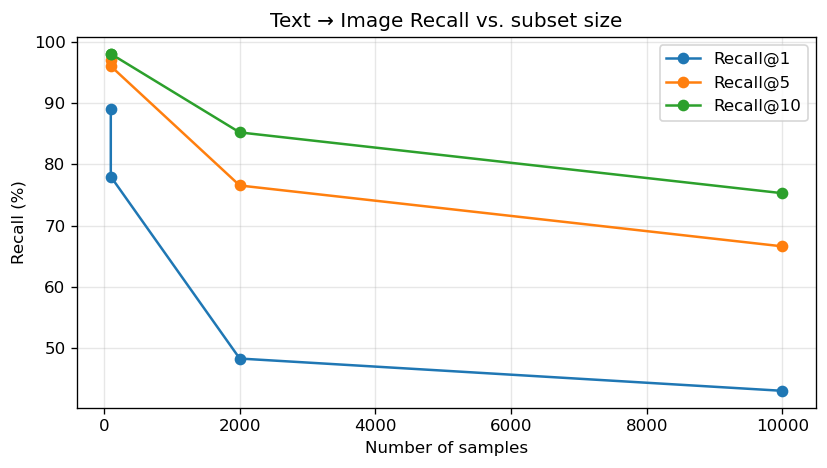

In [15]:
plt.figure(figsize=(7,4))
for k, color in zip((1,5,10), ("tab:blue", "tab:orange", "tab:green")):
    subset = df.dropna(subset=[f"R@{k}"])
    if subset.empty: continue
    plt.plot(subset["samples"], subset[f"R@{k}"], marker="o",
             label=f"Recall@{k}", color=color)

plt.xlabel("Number of samples")
plt.ylabel("Recall (%)")
plt.title("Text → Image Recall vs. subset size")
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()
plt.show()


# Bar plot: cross-domain image↔image Recall@1

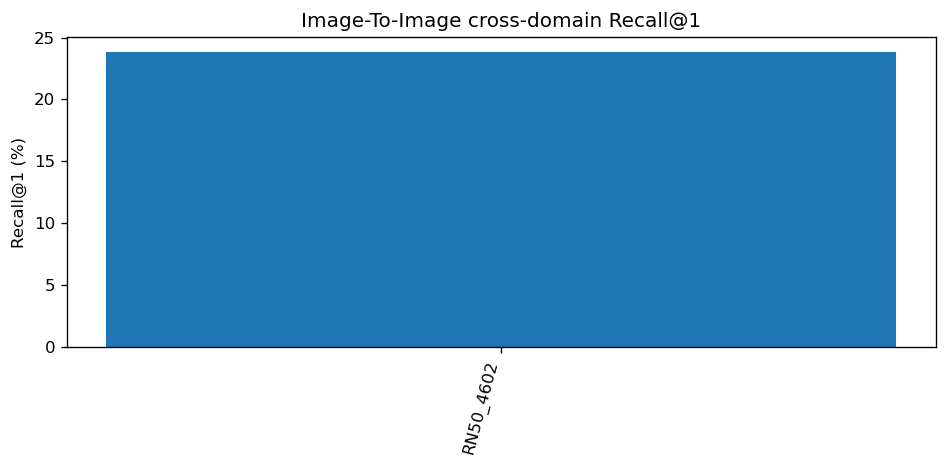

In [16]:
metric = "cross_domain_R@1"
sub = df.dropna(subset=[metric]).sort_values(metric, ascending=False)

plt.figure(figsize=(8,4))
plt.bar(sub["label"], sub[metric])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Recall@1 (%)")
plt.title("Image-To-Image cross-domain Recall@1")
plt.tight_layout()
plt.show()


# Radar chart comparing two or more runs

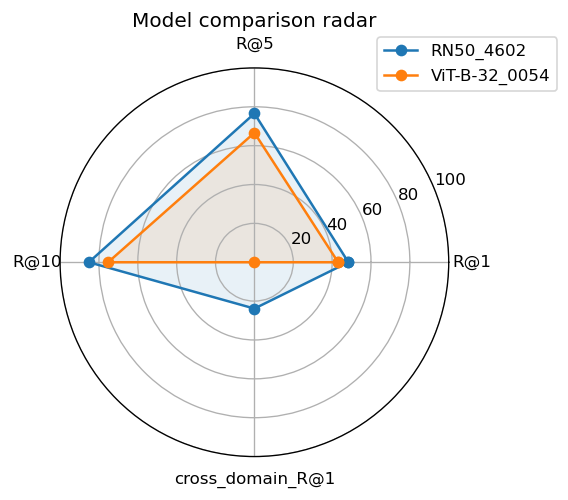

In [ ]:
def radar_compare(run_labels: List[str], metrics=("R@1","R@5","R@10",
                                                 "cross_domain_R@1")):
    from math import pi
    data = df.set_index("label").loc[run_labels, metrics].fillna(0)
    n_metrics = len(metrics)

    angles = [n / float(n_metrics) * 2 * pi for n in range(n_metrics)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(polar=True))
    for label, row in data.iterrows():
        values = row.tolist() + row.tolist()[:1]
        ax.plot(angles, values, marker="o", label=label)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 100)
    ax.set_title("Model comparison radar")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# compare last two runs
if len(df) >= 2:
    radar_compare(df["label"].tail(2).tolist())


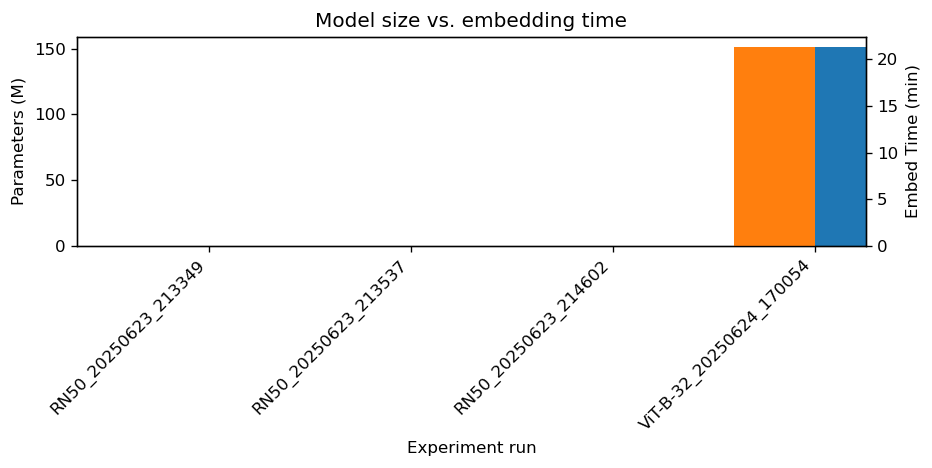

In [ ]:
# Cost vs. Performance (parameters & embed time)
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

EXP_ROOT = Path("experiments")
records = []
for d in EXP_ROOT.iterdir():
    cfg_path = d/"config.json"
    if not cfg_path.exists():
        continue
    cfg = json.loads(cfg_path.read_text())
    params = cfg.get("param_count", np.nan) / 1e6    
    embedm = cfg.get("embed_secs",  np.nan) / 60.0   
    records.append({
        "run":       d.name,
        "Parameters (M)": params,
        "Embed Time (min)": embedm
    })

df_cost = pd.DataFrame(records).sort_values("run").reset_index(drop=True)
df_cost

fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()

# bar for parameters
df_cost.plot(
    x="run", y="Parameters (M)", kind="bar",
    ax=ax1, position=0, width=0.4, color="C0", legend=False
)
# bar for embed time
df_cost.plot(
    x="run", y="Embed Time (min)", kind="bar",
    ax=ax2, position=1, width=0.4, color="C1", legend=False
)

ax1.set_ylabel("Parameters (M)")
ax2.set_ylabel("Embed Time (min)")
ax1.set_xticklabels(df_cost["run"], rotation=45, ha="right")
ax1.set_xlabel("Experiment run")
plt.title("Model size vs. embedding time")
plt.tight_layout()
plt.show()
